In [13]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import re
import os
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import multilabel_confusion_matrix
from statistics import mean
import math
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import matthews_corrcoef
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

In [ ]:
!nvidia-smi


Sat Sep 20 18:47:43 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

# Read CSV into dataframe
df = pd.read_csv('/content/drive/MyDrive/Dataset/Final FV/COMBINE FILE-FV/DATASET 3.csv')

# Separate labels (target column)
labels = df['label']

# Drop the label column from features
feature = df.drop(columns=['label'])

# Check shapes
print("Features shape:", feature.shape)
print("Labels shape:", labels.shape)


Features shape: (98041, 521)
Labels shape: (98041,)


**Label Encoder**

In [4]:
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
feature = feature.apply(le.fit_transform)

In [5]:
labels.shape


(98041,)

In [ ]:
import seaborn as sns
countplt, ax = plt.subplots(figsize = (10,7))
ax = sns.countplot(labels ,palette="Set2")

/tmp/ipython-input-1470246520.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(labels ,palette="Set2")


KeyboardInterrupt: 

**Standard Scaler For Features Scaling**

In [6]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.get_params()
feature=scaler.fit_transform(feature)

In [7]:
print(np.any(np.isinf(feature)))
print(np.any(np.isinf(labels)))


False
False


# **SELF CONSISTENCY TEST**

Self-Consistency Accuracy: 97.19%

Confusion Matrix:
 [[47073  1968]
 [  785 48215]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97     49041
           1       0.96      0.98      0.97     49000

    accuracy                           0.97     98041
   macro avg       0.97      0.97      0.97     98041
weighted avg       0.97      0.97      0.97     98041


MCC ---> 0.9441


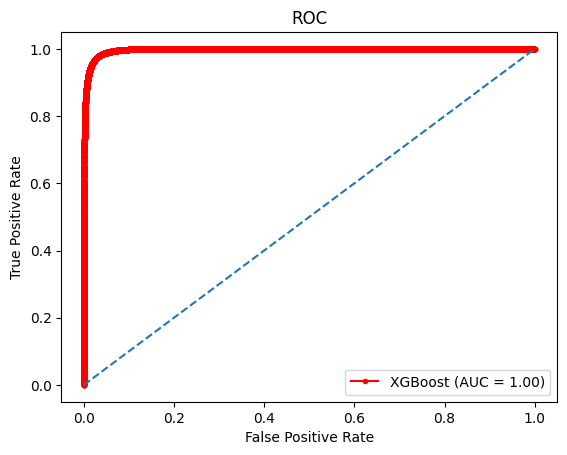

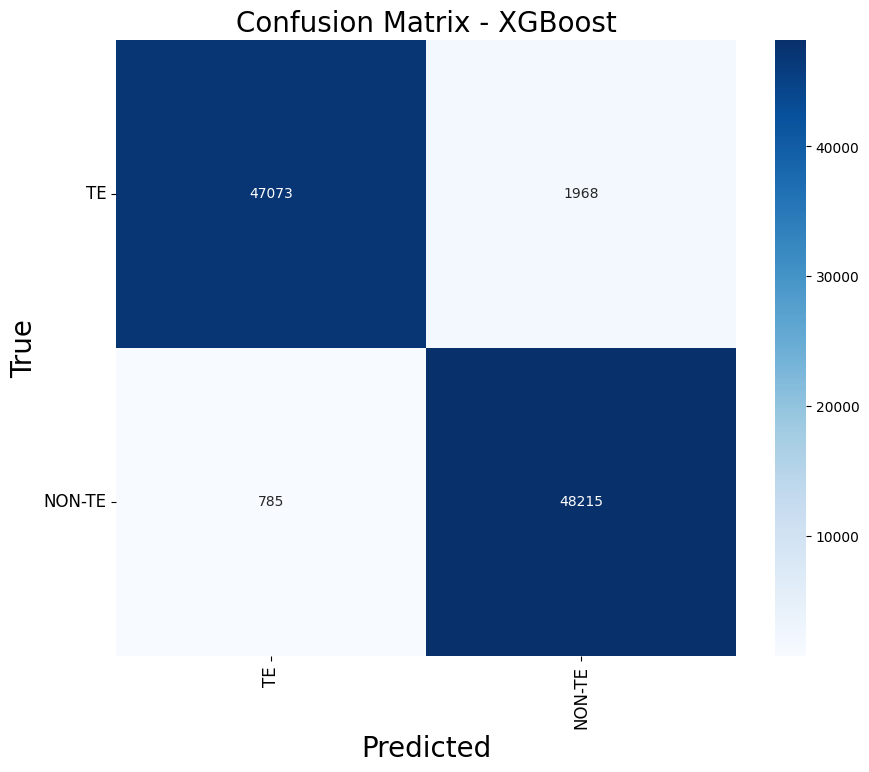

In [ ]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef

# ==============================
# Define optimized model
# ==============================
xgb_model = XGBClassifier(n_estimators=100)

# ==============================
# Train on ALL data (self-consistency)
# ==============================
xgb_model.fit(feature, labels)

# ==============================
# Predictions
# ==============================
y_pred = xgb_model.predict(feature)
pred_prob = xgb_model.predict_proba(feature)

# ==============================
# Evaluation
# ==============================
print('Self-Consistency Accuracy: {:.2f}%'.format(100 * accuracy_score(labels, y_pred)))

cm_xgb = confusion_matrix(labels, y_pred)
print("\nConfusion Matrix:\n", cm_xgb)

print("\nClassification Report:\n", classification_report(labels, y_pred))

mcc = matthews_corrcoef(labels, y_pred)
print("\nMCC ---> {:.4f}".format(mcc))

#AUC SCORE
fpr_xg = {}
tpr_xg = {}
thresh_xg ={}

n_class = 2

for i in range(n_class):
    fpr_xg[i], tpr_xg[i], thresh_xg[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_xg = auc(fpr_xg[i], tpr_xg[i])
roc_xg
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_xg[i], tpr_xg[i], marker='.', color='red',
         label='XGBoost (AUC = %0.2f)' % roc_xg)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

# Show legend
plt.legend()

# Save plot
plt.savefig('self-test-xgb_roc.png')

# Show plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, y_pred)

# Define class labels
class_names = ['TE','NON-TE']

# Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - XGBoost', fontsize=20)

# Save & show
plt.savefig('xgb_self-test_cm.png')
plt.show()



Self-Consistency Accuracy: 97.19%

Confusion Matrix:
 [[47073  1968]
 [  785 48215]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97     49041
           1       0.96      0.98      0.97     49000

    accuracy                           0.97     98041
   macro avg       0.97      0.97      0.97     98041
weighted avg       0.97      0.97      0.97     98041


MCC ---> 0.9441


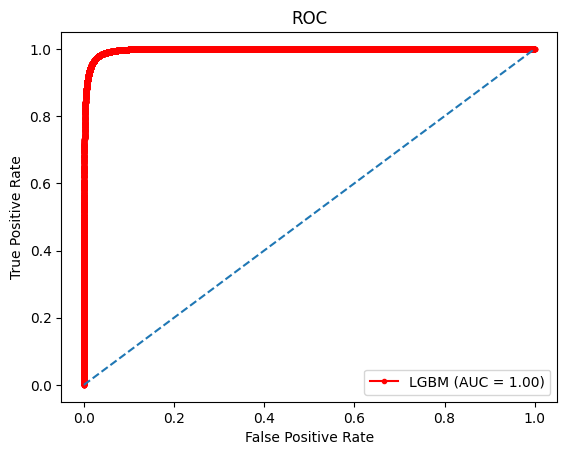

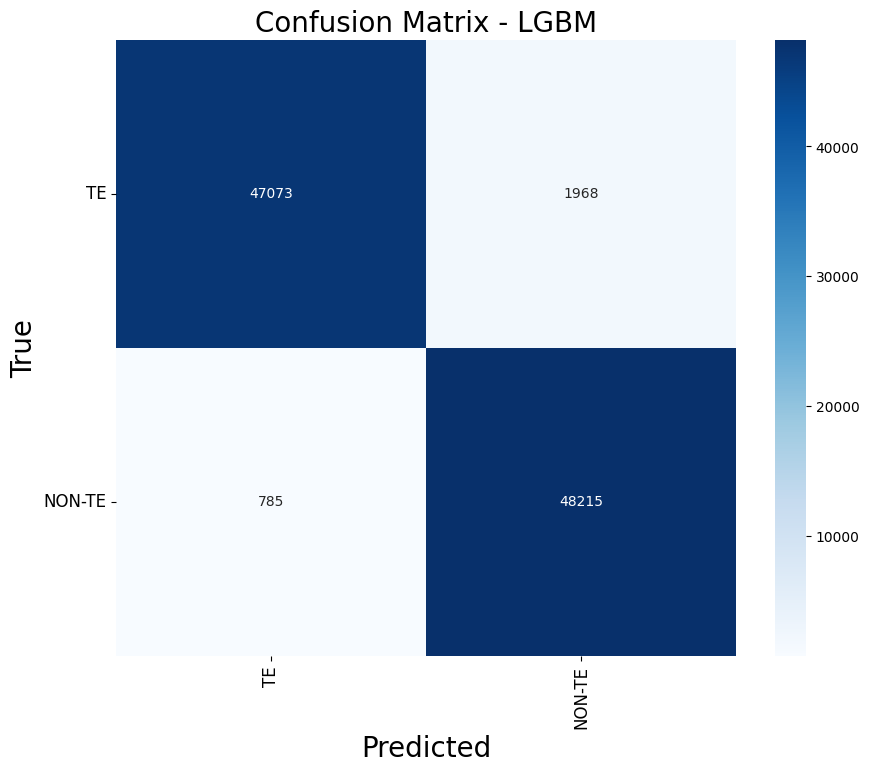

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef, roc_curve, auc
from lightgbm import LGBMClassifier

# ==============================
# Define optimized LightGBM model
# ==============================
lgbm_model = LGBMClassifier(
    n_estimators=100
)

import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef

# ==============================
# Define optimized model
# ==============================
lgbm_model = XGBClassifier(n_estimators=100)

# ==============================
# Train on ALL data (self-consistency)
# ==============================
lgbm_model.fit(feature, labels)

# ==============================
# Predictions
# ==============================
y_pred = lgbm_model.predict(feature)
pred_prob = lgbm_model.predict_proba(feature)

# ==============================
# Evaluation
# ==============================
print('Self-Consistency Accuracy: {:.2f}%'.format(100 * accuracy_score(labels, y_pred)))

cm_lgbm = confusion_matrix(labels, y_pred)
print("\nConfusion Matrix:\n", cm_lgbm)

print("\nClassification Report:\n", classification_report(labels, y_pred))

mcc = matthews_corrcoef(labels, y_pred)
print("\nMCC ---> {:.4f}".format(mcc))

#AUC SCORE
fpr_lgbm = {}
tpr_lgbm = {}
thresh_lgbm ={}


n_class = 2

for i in range(n_class):
    fpr_lgbm[i], tpr_lgbm[i], thresh_lgbm[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_lgbm = auc(fpr_lgbm[i], tpr_lgbm[i])
roc_lgbm
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_lgbm[i], tpr_lgbm[i], marker='.', color='red',
         label='LGBM (AUC = %0.2f)' % roc_lgbm)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

# Show legend
plt.legend()

# Save plot
plt.savefig('self-test-lgbm_roc.png')

# Show plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, y_pred)

# Define class labels
class_names = ['TE','NON-TE']

# Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - LGBM', fontsize=20)

# Save & show
plt.savefig('lgbm_self-test_cm.png')
plt.show()



Self-Consistency Accuracy: 99.37%

Confusion Matrix:
 [[48790   251]
 [  365 48635]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99     49041
           1       0.99      0.99      0.99     49000

    accuracy                           0.99     98041
   macro avg       0.99      0.99      0.99     98041
weighted avg       0.99      0.99      0.99     98041


MCC ---> 0.9874


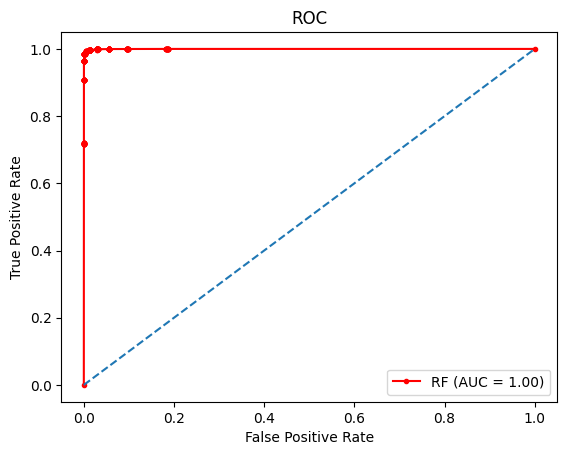

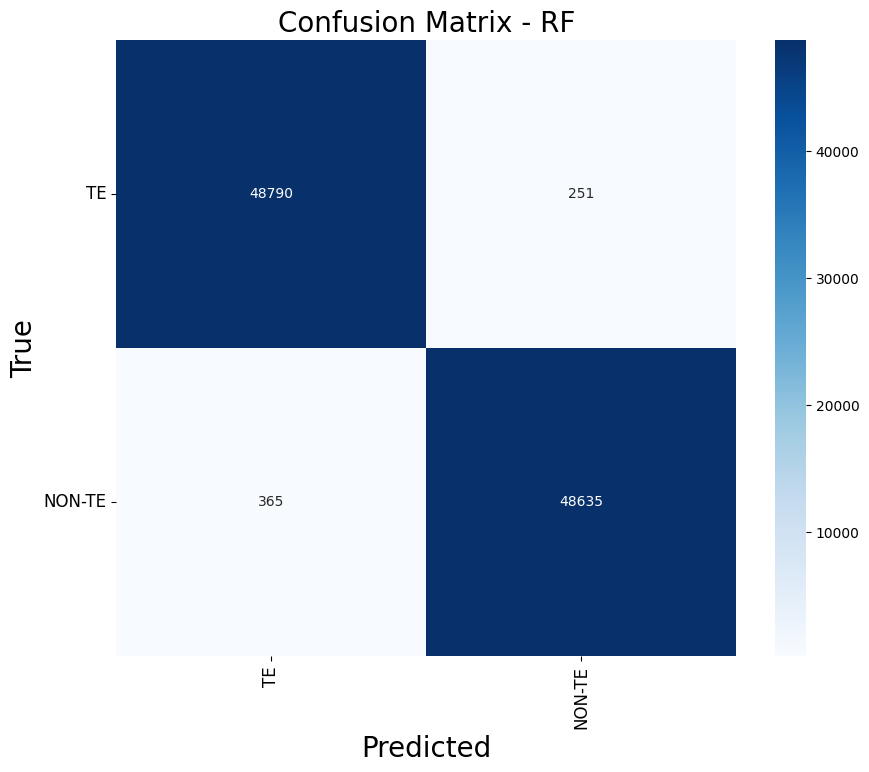

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    matthews_corrcoef, roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import label_binarize

# ==============================
# Define Random Forest model
# ==============================
rf_model = RandomForestClassifier(n_estimators=10, random_state=10)
# ==============================
# Train on ALL data (self-consistency)
# ==============================
rf_model.fit(feature, labels)

# ==============================
# Predictions
# ==============================
y_pred = rf_model.predict(feature)
pred_prob = rf_model.predict_proba(feature)

# ==============================
# Evaluation
# ==============================
print('Self-Consistency Accuracy: {:.2f}%'.format(100 * accuracy_score(labels, y_pred)))

cm_rf = confusion_matrix(labels, y_pred)
print("\nConfusion Matrix:\n", cm_rf)

print("\nClassification Report:\n", classification_report(labels, y_pred))

mcc = matthews_corrcoef(labels, y_pred)
print("\nMCC ---> {:.4f}".format(mcc))

#AUC SCORE
fpr_rf = {}
tpr_rf = {}
thresh_rf ={}


n_class = 2

for i in range(n_class):
    fpr_rf[i], tpr_rf[i], thresh_rf[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_rf = auc(fpr_rf[i], tpr_rf[i])
roc_rf
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_rf[i], tpr_rf[i], marker='.', color='red',
         label='RF (AUC = %0.2f)' % roc_rf)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

# Show legend
plt.legend()

# Save plot
plt.savefig('self-test-rf_roc.png')

# Show plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, y_pred)

# Define class labels
class_names = ['TE','NON-TE']

# Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - RF', fontsize=20)

# Save & show
plt.savefig('rf_self-test_cm.png')
plt.show()



Self-Consistency Accuracy: 99.75%

Confusion Matrix:
 [[49025    16]
 [  227 48773]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     49041
           1       1.00      1.00      1.00     49000

    accuracy                           1.00     98041
   macro avg       1.00      1.00      1.00     98041
weighted avg       1.00      1.00      1.00     98041


MCC ---> 0.9951


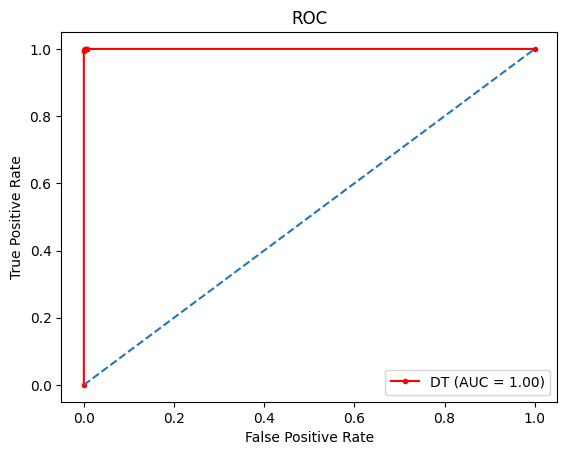

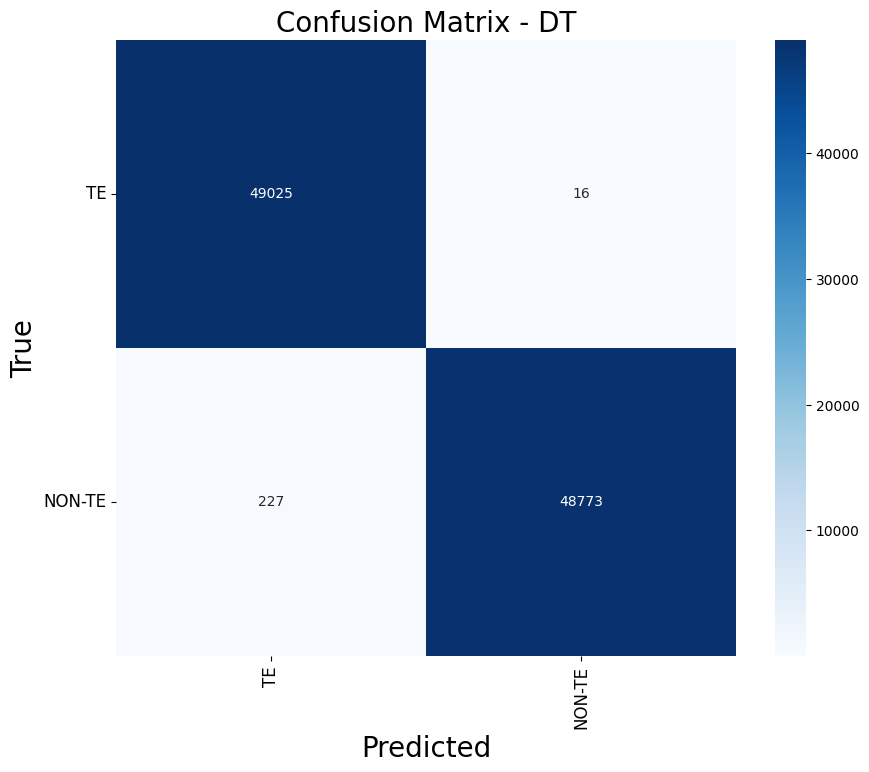

In [ ]:
 dt_model = DecisionTreeClassifier()
# train the model using X_train_dtm & y_train

# ==============================
# Train on ALL data (self-consistency)
# ==============================
dt_model.fit(feature, labels)

# ==============================
# Predictions
# ==============================
y_pred = dt_model.predict(feature)
pred_prob = dt_model.predict_proba(feature)

# ==============================
# Evaluation
# ==============================
print('Self-Consistency Accuracy: {:.2f}%'.format(100 * accuracy_score(labels, y_pred)))

cm_dt = confusion_matrix(labels, y_pred)
print("\nConfusion Matrix:\n", cm_dt)

print("\nClassification Report:\n", classification_report(labels, y_pred))

mcc = matthews_corrcoef(labels, y_pred)
print("\nMCC ---> {:.4f}".format(mcc))

#AUC SCORE
fpr_dt = {}
tpr_dt = {}
thresh_dt ={}


n_class = 2

for i in range(n_class):
    fpr_dt[i], tpr_dt[i], thresh_dt[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_dt = auc(fpr_dt[i], tpr_dt[i])
roc_dt
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_dt[i], tpr_dt[i], marker='.', color='red',
         label='DT (AUC = %0.2f)' % roc_dt)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

# Show legend
plt.legend()

# Save plot
plt.savefig('self-test-dt_roc.png')

# Show plot
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(labels, y_pred)

# Define class labels
class_names = ['TE','NON-TE']

# Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - DT', fontsize=20)

# Save & show
plt.savefig('dt_self-test_cm.png')
plt.show()


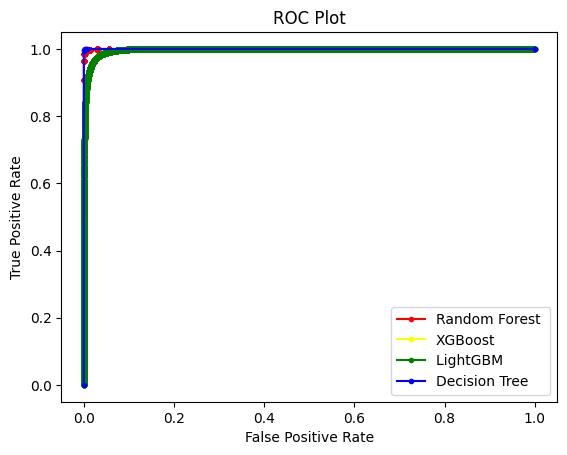

In [ ]:
import matplotlib.pyplot as plt
plt.plot(fpr_rf[i],tpr_rf[i], marker='.',color='red',label = 'Random Forest ' % roc_rf)
plt.plot(fpr_xg[i],tpr_xg[i], marker='.',color='yellow',label = 'XGBoost' % roc_xg)
plt.plot(fpr_lgbm[i],tpr_lgbm[i], marker='.',color='green',label = 'LightGBM ' % roc_lgbm)
plt.plot(fpr_dt[i],tpr_dt[i], marker='.',color='blue',label = 'Decision Tree' % roc_dt)
plt.title('ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #
plt.savefig('self-test_roc.png')
# Show plot
plt.show()


**INDEPENDENT TESTING**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(feature, labels, test_size=0.3, random_state=100,stratify=labels)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(68628, 521) (29413, 521)
(68628,) (29413,)


Training accuracy is 0.9786967418546366
Test accuracy is 0.9368646516846293
[[13547  1166]
 [  691 14009]]
              precision    recall  f1-score   support

           0       0.95      0.92      0.94     14713
           1       0.92      0.95      0.94     14700

    accuracy                           0.94     29413
   macro avg       0.94      0.94      0.94     29413
weighted avg       0.94      0.94      0.94     29413

Accuracy 93.69%
MCC ---> 0.8741871644372363
Sensitivity :  0.9207503568272956
Specificity :  0.9529931972789115


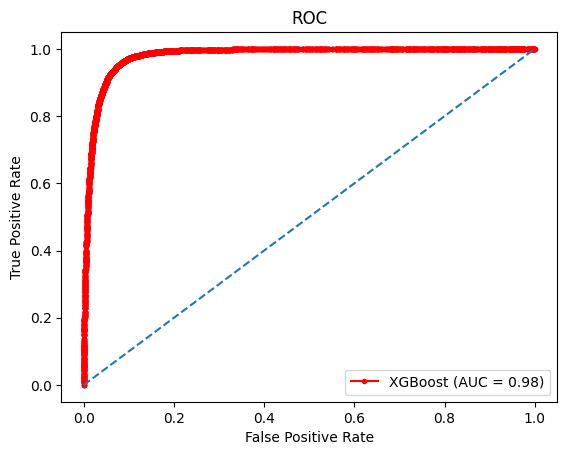

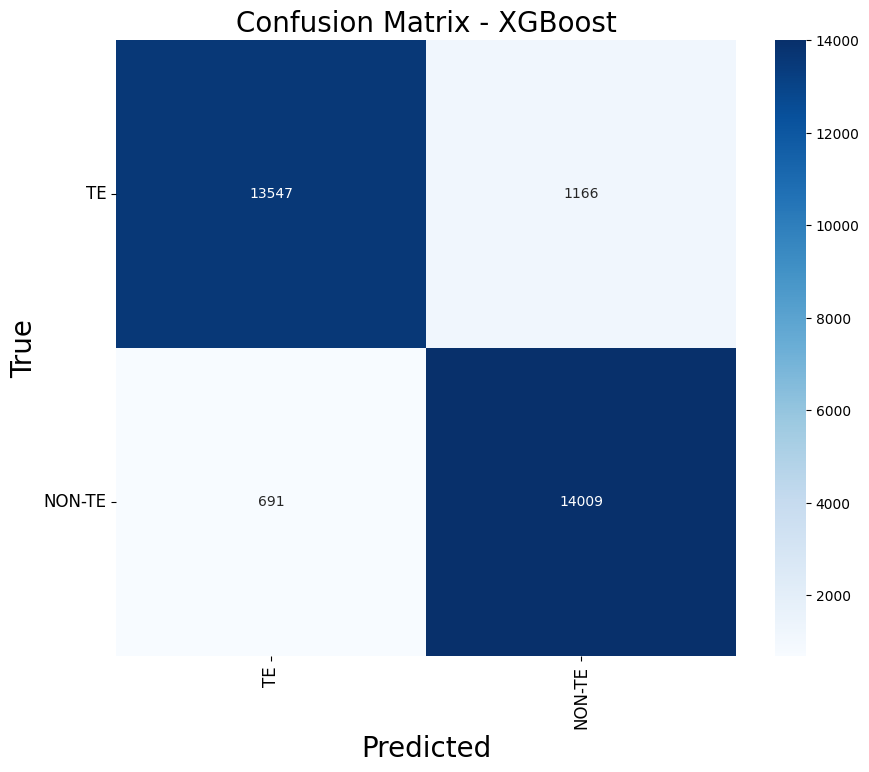

In [ ]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, matthews_corrcoef
xgb1 = XGBClassifier(n_estimators=100)
xgb1.fit(X_train, y_train)
# compute the training accuracy
y_pred_train = xgb1.predict(X_train)
print('Training accuracy is {}'.format(accuracy_score(y_train, y_pred_train)))

y_pred_test = xgb1.predict(X_test)
print('Test accuracy is {}'.format(accuracy_score(y_test, y_pred_test)))

pred_prob = xgb1.predict_proba(X_test)

cm_xgb1 = confusion_matrix(y_test, y_pred_test)
print(cm_xgb1)

cr_xgb1 = classification_report(y_test, y_pred_test)
print(cr_xgb1)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(y_test, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity (only valid for binary classification)
sensitivity1 = cm_xgb1[0,0] / (cm_xgb1[0,0] + cm_xgb1[0,1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_xgb1[1,1] / (cm_xgb1[1,0] + cm_xgb1[1,1])
print('Specificity : ', specificity1)

# AUC SCORE
fpr_xgb1 = {}
tpr_xgb1 = {}
thresh_xgb1 = {}

n_class = 2

for i in range(n_class):
    fpr_xgb1[i], tpr_xgb1[i], thresh_xgb1[i] = roc_curve(y_test, pred_prob[:, i], pos_label=i)
    roc_xgb1 = auc(fpr_xgb1[i], tpr_xgb1[i])

roc_xgb1
import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_xgb1[i], tpr_xgb1[i], marker='.', color='red',
         label='XGBoost (AUC = %0.2f)' % roc_xgb1)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
# Show legend
plt.legend()
plt.savefig('INDEP-test-xgb1_roc.png')
# Show plot
plt.show()



### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred_test)

## Get Class Labels
labels = ['TE','NON-TE']
class_names = labels

## Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - XGBoost', fontsize=20)

# Save & show
plt.savefig('xgb1_indep-test_cm.png')
plt.show()


Training accuracy is 0.9942589030716326
Test accuracy is 0.9274130486519566
[[13549  1164]
 [  971 13729]]
              precision    recall  f1-score   support

           0       0.93      0.92      0.93     14713
           1       0.92      0.93      0.93     14700

    accuracy                           0.93     29413
   macro avg       0.93      0.93      0.93     29413
weighted avg       0.93      0.93      0.93     29413

Accuracy 92.74%
MCC ---> 0.8549005309228248
Sensitivity :  0.920886291035139
Specificity :  0.9339455782312925


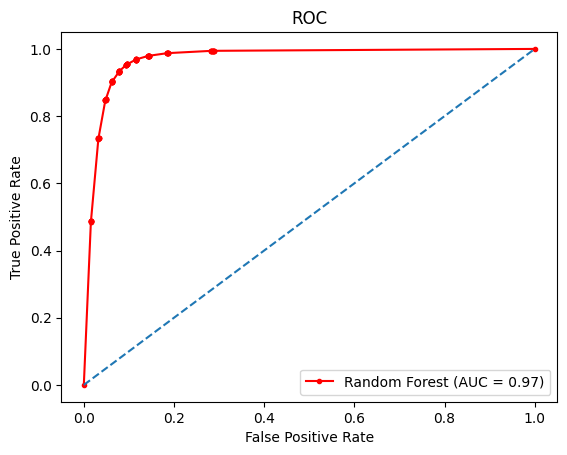

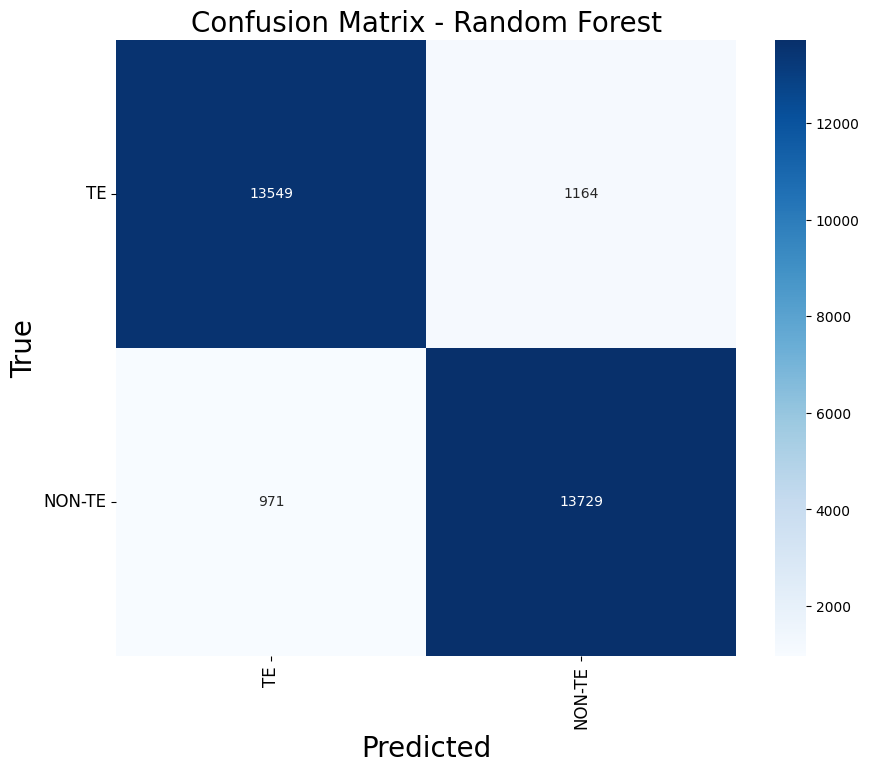

In [ ]:
rclf1 = RandomForestClassifier(n_estimators=10,random_state=10)
rclf1.fit(X_train, y_train)
rclf1.fit(X_train, y_train)
# compute the training accuracy
y_pred_train = rclf1.predict(X_train)
print('Training accuracy is {}'.format(accuracy_score(y_train, y_pred_train)))

y_pred_test = rclf1.predict(X_test)
print('Test accuracy is {}'.format(accuracy_score(y_test, y_pred_test)))

pred_prob = rclf1.predict_proba(X_test)

cm_rclf1 = confusion_matrix(y_test, y_pred_test)
print(cm_rclf1)

cr_rclf1 = classification_report(y_test, y_pred_test)
print(cr_rclf1)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(y_test, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity (only valid for binary classification)
sensitivity1 = cm_rclf1[0,0] / (cm_rclf1[0,0] + cm_rclf1[0,1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_rclf1[1,1] / (cm_rclf1[1,0] + cm_rclf1[1,1])
print('Specificity : ', specificity1)

# AUC SCORE
fpr_rclf1 = {}
tpr_rclf1 = {}
thresh_rclf1 = {}

n_class = 2

for i in range(n_class):
    fpr_rclf1[i], tpr_rclf1[i], thresh_rclf1[i] = roc_curve(y_test, pred_prob[:, i], pos_label=i)
    roc_rclf1 = auc(fpr_rclf1[i], tpr_rclf1[i])

roc_rclf1

import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_rclf1[i], tpr_rclf1[i], marker='.', color='red',
         label='Random Forest (AUC = %0.2f)' % roc_rclf1)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
# Show legend
plt.legend()
plt.savefig('INDEP-test-rclf1_roc.png')
# Show plot
plt.show()



### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

## Get Class Labels
labels = ['TE','NON-TE']
class_names = labels

## Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - Random Forest', fontsize=20)

# Save & show
plt.savefig('rclf1_indep-test_cm.png')
plt.show()


Training accuracy is 0.998062015503876
Test accuracy is 0.8967123380818006
[[13290  1423]
 [ 1615 13085]]
              precision    recall  f1-score   support

           0       0.89      0.90      0.90     14713
           1       0.90      0.89      0.90     14700

    accuracy                           0.90     29413
   macro avg       0.90      0.90      0.90     29413
weighted avg       0.90      0.90      0.90     29413

Accuracy 89.67%
MCC ---> 0.7934910707167799
Sensitivity :  0.9032828111194182
Specificity :  0.8901360544217687


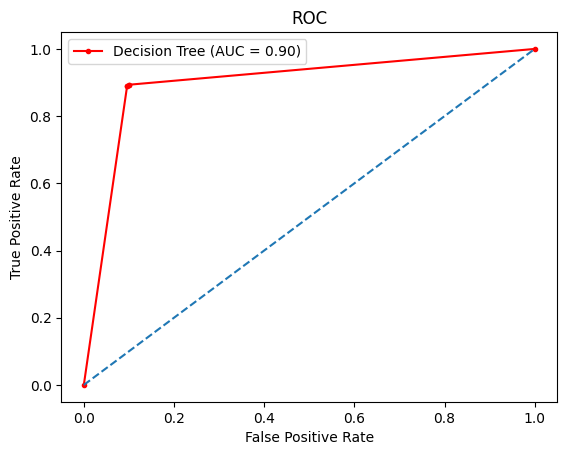

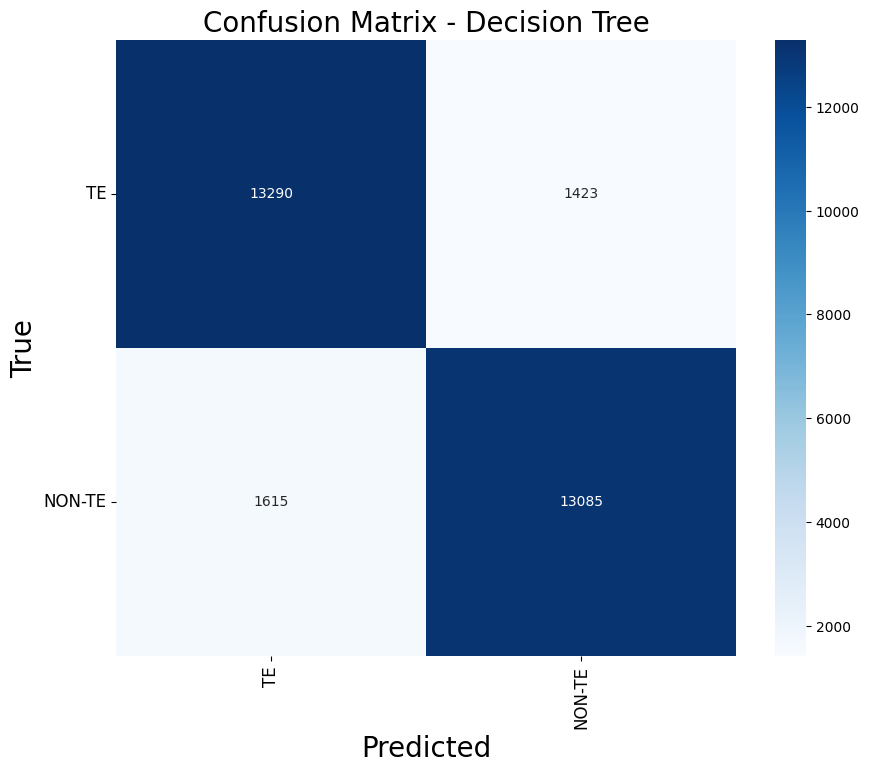

In [ ]:
dt1 = DecisionTreeClassifier()
dt1.fit(X_train, y_train)
# compute the training accuracy
y_pred_train = dt1.predict(X_train)
print('Training accuracy is {}'.format(accuracy_score(y_train, y_pred_train)))

y_pred_test = dt1.predict(X_test)
print('Test accuracy is {}'.format(accuracy_score(y_test, y_pred_test)))

pred_prob = dt1.predict_proba(X_test)

cm_dt1 = confusion_matrix(y_test, y_pred_test)
print(cm_dt1)

cr_dt1 = classification_report(y_test, y_pred_test)
print(cr_dt1)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(y_test, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity (only valid for binary classification)
sensitivity1 = cm_dt1[0,0] / (cm_dt1[0,0] + cm_dt1[0,1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_dt1[1,1] / (cm_dt1[1,0] + cm_dt1[1,1])
print('Specificity : ', specificity1)

# AUC SCORE
fpr_dt1 = {}
tpr_dt1 = {}
thresh_dt1 = {}

n_class = 2

for i in range(n_class):
    fpr_dt1[i], tpr_dt1[i], thresh_dt1[i] = roc_curve(y_test, pred_prob[:, i], pos_label=i)
    roc_dt1 = auc(fpr_dt1[i], tpr_dt1[i])

roc_dt1

import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_dt1[i], tpr_dt1[i], marker='.', color='red',
         label='Decision Tree (AUC = %0.2f)' % roc_dt1)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
# Show legend
plt.legend()
plt.savefig('INDEP-test-dt1_roc.png')
# Show plot
plt.show()



### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

## Get Class Labels
labels = ['TE','NON-TE']
class_names = labels

## Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - Decision Tree', fontsize=20)

# Save & show
plt.savefig('dt1_indep-test_cm.png')
plt.show()



[LightGBM] [Info] Number of positive: 34300, number of negative: 34328
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.982116 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127478
[LightGBM] [Info] Number of data points in the train set: 68628, number of used features: 516
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499796 -> initscore=-0.000816
[LightGBM] [Info] Start training from score -0.000816


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training accuracy is 0.94812612927668


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Test accuracy is 0.9325468330330127


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[[13452  1261]
 [  723 13977]]
              precision    recall  f1-score   support

           0       0.95      0.91      0.93     14713
           1       0.92      0.95      0.93     14700

    accuracy                           0.93     29413
   macro avg       0.93      0.93      0.93     29413
weighted avg       0.93      0.93      0.93     29413

Accuracy 93.25%
MCC ---> 0.8656752528448721
Sensitivity :  0.9142934819547339
Specificity :  0.9508163265306122


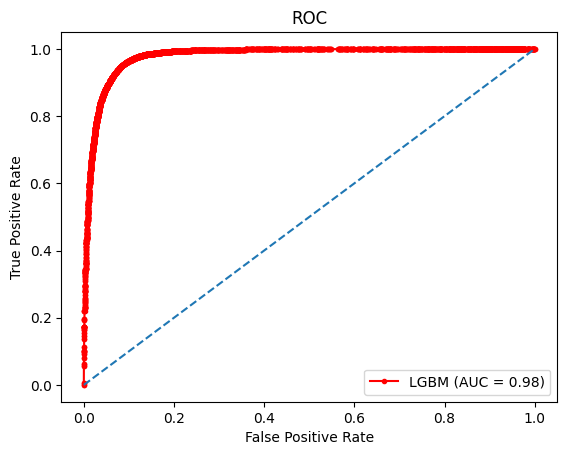

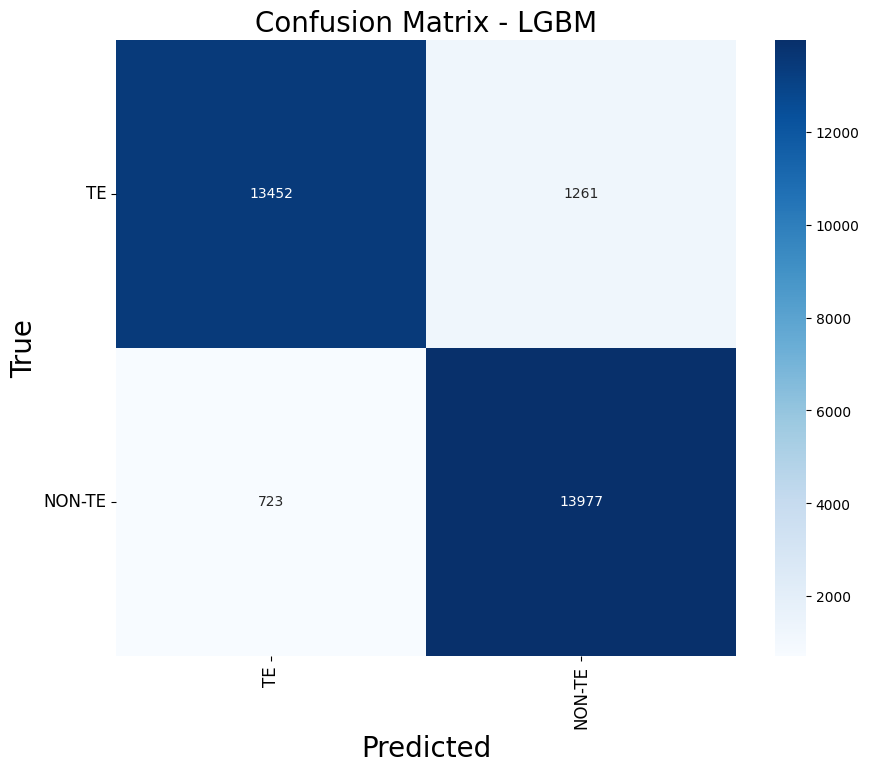

In [ ]:

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier

lgbm1 = LGBMClassifier(
    n_estimators=100
)

lgbm1.fit(X_train, y_train)

# compute the training accuracy
y_pred_train = lgbm1.predict(X_train)
print('Training accuracy is {}'.format(accuracy_score(y_train, y_pred_train)))

y_pred_test = lgbm1.predict(X_test)
print('Test accuracy is {}'.format(accuracy_score(y_test, y_pred_test)))

pred_prob = lgbm1.predict_proba(X_test)

cm_lgbm1 = confusion_matrix(y_test, y_pred_test)
print(cm_lgbm1)

cr_lgbm1 = classification_report(y_test, y_pred_test)
print(cr_lgbm1)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(y_test, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(y_test, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity (only valid for binary classification)
sensitivity1 = cm_lgbm1[0,0] / (cm_lgbm1[0,0] + cm_lgbm1[0,1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_lgbm1[1,1] / (cm_lgbm1[1,0] + cm_lgbm1[1,1])
print('Specificity : ', specificity1)

# AUC SCORE
fpr_lgbm1 = {}
tpr_lgbm1 = {}
thresh_lgbm1 = {}

n_class = 2

for i in range(n_class):
    fpr_lgbm1[i], tpr_lgbm1[i], thresh_lgbm1[i] = roc_curve(y_test, pred_prob[:, i], pos_label=i)
    roc_lgbm1 = auc(fpr_lgbm1[i], tpr_lgbm1[i])

roc_lgbm1

import matplotlib.pyplot as plt

plt.title('ROC')
plt.plot(fpr_lgbm1[i], tpr_lgbm1[i], marker='.', color='red',
         label='LGBM (AUC = %0.2f)' % roc_lgbm1)
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
# Show legend
plt.legend()
plt.savefig('INDEP-test-lgbm1_roc.png')
# Show plot
plt.show()


### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_test)

## Get Class Labels
labels = ['TE','NON-TE']
class_names = labels

## Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - LGBM', fontsize=20)

# Save & show
plt.savefig('lgbm1_indep-test_cm.png')
plt.show()


**ROC-INDEPENDENT TEST**

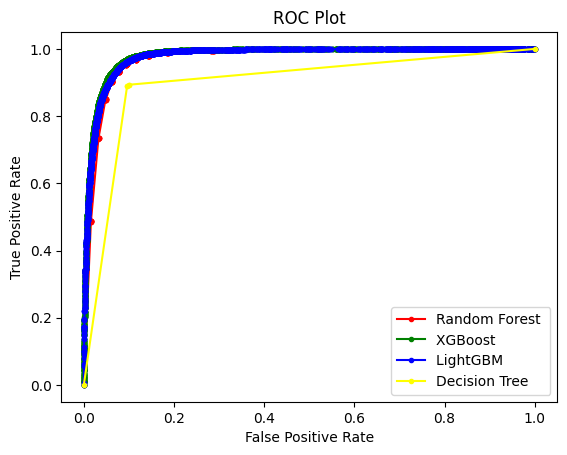

In [ ]:
import matplotlib.pyplot as plt
plt.plot(fpr_rclf1[i],tpr_rclf1[i], marker='.',color='red',label = 'Random Forest ' % roc_rclf1)
plt.plot(fpr_xgb1[i],tpr_xgb1[i], marker='.',color='green',label = 'XGBoost ' % roc_xgb1)
plt.plot(fpr_lgbm1[i],tpr_lgbm1[i], marker='.',color='blue',label = 'LightGBM ' % roc_lgbm1)
plt.plot(fpr_dt1[i],tpr_dt1[i], marker='.',color='yellow',label = 'Decision Tree ' % roc_dt1)
plt.title('ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #
plt.savefig('INDE-test_roc.png')
# Show plot
plt.show()


# **Cross Validation Test**

In [8]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score,matthews_corrcoef

Mean of Accuracies:  90.68045023615333
[[43684  5357]
 [ 3780 45220]]
              precision    recall  f1-score   support

           0       0.92      0.89      0.91     49041
           1       0.89      0.92      0.91     49000

    accuracy                           0.91     98041
   macro avg       0.91      0.91      0.91     98041
weighted avg       0.91      0.91      0.91     98041

Accuracy 90.68%
MCC ---> 0.8140323954327099
Sensitivity :  0.8907648702106401
Specificity :  0.9228571428571428


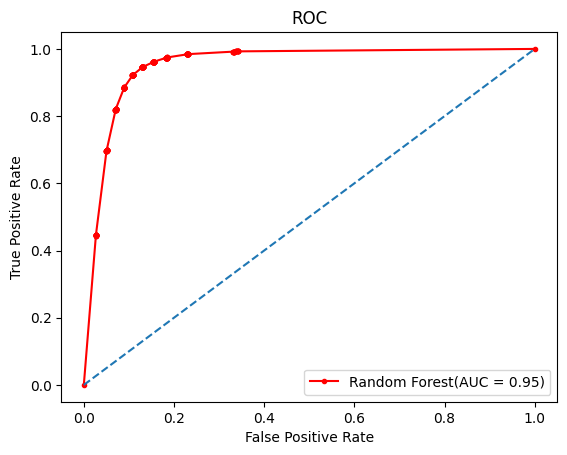

NameError: name 'cm' is not defined

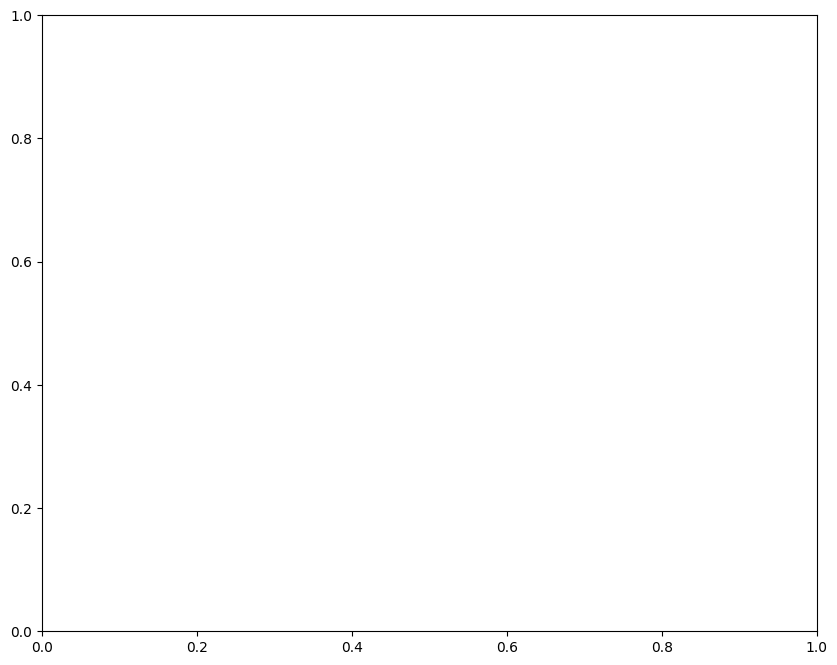

In [9]:
rclf2 = RandomForestClassifier(n_estimators=10,random_state=10)
rclf2.fit(feature,labels)
score_rclf2 = cross_val_score(rclf2, feature , labels, cv = 10)
res=score_rclf2.mean()
print('Mean of Accuracies: ',res*100,end='\n')
pred_prob =cross_val_predict(rclf2, feature , labels, cv = 10 ,method='predict_proba')
y_pred_test = cross_val_predict(rclf2, feature , labels, cv = 10)
cm_rf1=confusion_matrix(labels,y_pred_test)
print(cm_rf1)
cr_rf1=classification_report(labels,y_pred_test)
print(cr_rf1)
print("Accuracy {0:.2f}%".format(100*accuracy_score(labels, y_pred_test)))
# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(labels, y_pred_test)
print("MCC ---> {0}".format(mcc))
sensitivity1 = cm_rf1[0,0]/(cm_rf1[0,0]+cm_rf1[0,1])
print('Sensitivity : ', sensitivity1 )

specificity1 = cm_rf1[1,1]/(cm_rf1[1,0]+cm_rf1[1,1])
print('Specificity : ', specificity1)



#AUC SCORE
fpr_rf2 = {}
tpr_rf2 = {}
thresh_rf2 ={}

n_class = 2

for i in range(n_class):
    fpr_rf2[i], tpr_rf2[i], thresh_rf2[i] = roc_curve(labels, pred_prob[:,i], pos_label=i)
    roc_rf2 = auc(fpr_rf2[i], tpr_rf2[i])
roc_rf2

import matplotlib.pyplot as plt
plt.title('ROC')
plt.plot(fpr_rf2[i], tpr_rf2[i], marker='.',color='red',label = 'Random Forest(AUC = %0.2f)' % roc_rf2)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
#Show legend
plt.legend()
plt.savefig('cross-val-test-rf_roc.png')
# Show plot
plt.show()





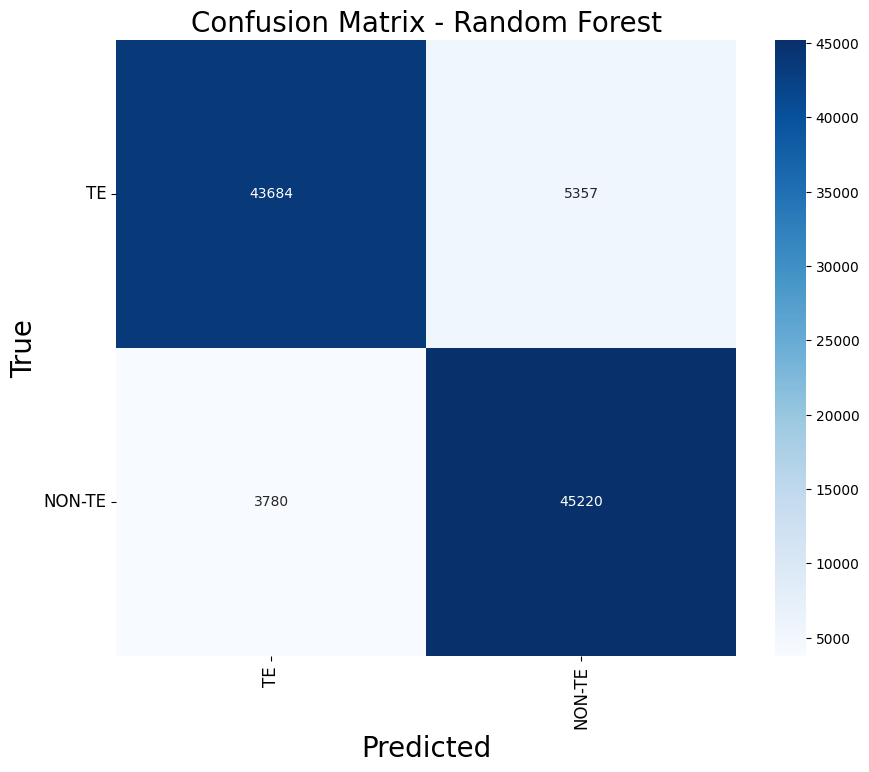

In [10]:
### Confusion Matrix
from sklearn.metrics import confusion_matrix

cm_rf1=confusion_matrix(labels,y_pred_test)

## Get Class Labels
label  = ['TE','NON-TE']
class_names = label

### Plot confusion matrix
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm_rf1, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - Random Forest', fontsize=20)

# Save & show

plt.savefig('rf_cross-val-_cm.png')
plt.show()

Mean of Accuracies:  91.39135885383085
[[43736  5305]
 [ 3135 45865]]
              precision    recall  f1-score   support

           0       0.93      0.89      0.91     49041
           1       0.90      0.94      0.92     49000

    accuracy                           0.91     98041
   macro avg       0.91      0.91      0.91     98041
weighted avg       0.91      0.91      0.91     98041

Accuracy 91.39%
MCC ---> 0.8286425565608837
Sensitivity :  0.8918252074794559
Specificity :  0.9360204081632653


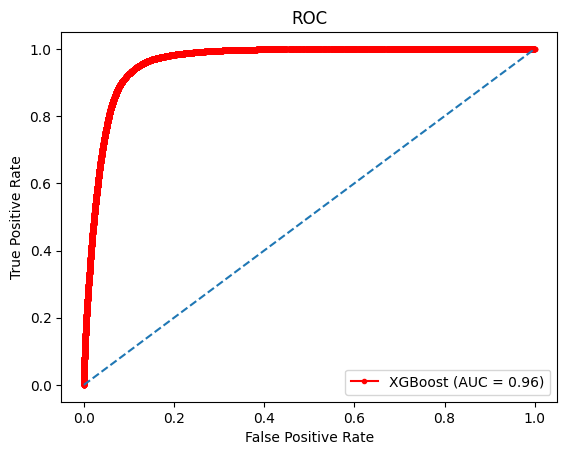

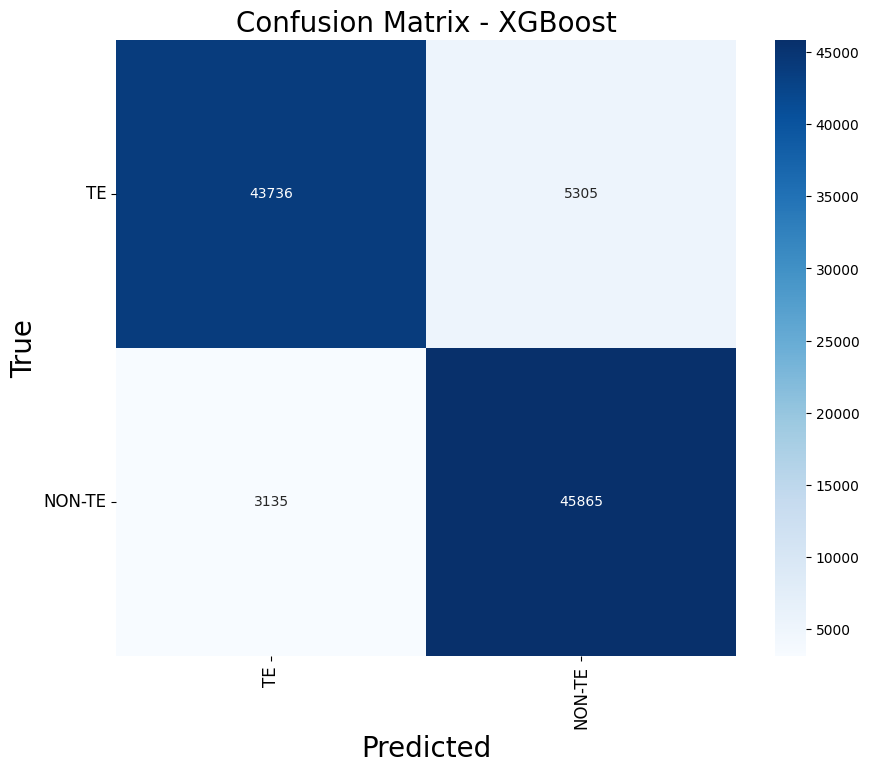

In [11]:
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    matthews_corrcoef, roc_curve, auc
)

# ------------------ Model ------------------
xgb2 = XGBClassifier(n_estimators=100)
xgb2.fit(feature, labels)

# Cross-validation accuracy
score_xgb2 = cross_val_score(xgb2, feature, labels, cv=10)
res = score_xgb2.mean()
print('Mean of Accuracies: ', res * 100, end='\n')

# Cross-validated predictions
pred_prob = cross_val_predict(xgb2, feature, labels, cv=10, method='predict_proba')
y_pred_test = cross_val_predict(xgb2, feature, labels, cv=10)

# ------------------ Metrics ------------------
cm_xgb2 = confusion_matrix(labels, y_pred_test)
print(cm_xgb2)

cr_xgb2 = classification_report(labels, y_pred_test)
print(cr_xgb2)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(labels, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(labels, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity
sensitivity1 = cm_xgb2[0, 0] / (cm_xgb2[0, 0] + cm_xgb2[0, 1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_xgb2[1, 1] / (cm_xgb2[1, 0] + cm_xgb2[1, 1])
print('Specificity : ', specificity1)

# ------------------ AUC SCORE ------------------
fpr_xgb2 = {}
tpr_xgb2 = {}
thresh_xgb2 = {}

n_class = 2
for i in range(n_class):
    fpr_xgb2[i], tpr_xgb2[i], thresh_xgb2[i] = roc_curve(labels, pred_prob[:, i], pos_label=i)
    roc_xgb2 = auc(fpr_xgb2[i], tpr_xgb2[i])
roc_xgb2

# ------------------ ROC Plot ------------------
plt.title('ROC')
plt.plot(fpr_xgb2[i], tpr_xgb2[i], marker='.', color='red',
         label='XGBoost (AUC = %0.2f)' % roc_xgb2)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

plt.legend()
plt.savefig('cross-val-test-xgb2_roc.png')
plt.show()

# ------------------ Confusion Matrix Heatmap ------------------
cm_xgb2 = confusion_matrix(labels, y_pred_test)
class_names = ['TE', 'NON-TE']

fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm_xgb2, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - XGBoost', fontsize=20)

plt.savefig('xgb2_cross-val_cm.png')
plt.show()


[LightGBM] [Info] Number of positive: 49000, number of negative: 49041
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.984234 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127973
[LightGBM] [Info] Number of data points in the train set: 98041, number of used features: 516
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499791 -> initscore=-0.000836
[LightGBM] [Info] Start training from score -0.000836
[LightGBM] [Info] Number of positive: 44100, number of negative: 44136
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.662510 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127962
[LightGBM] [Info] Number of data points in the train set: 88236, number of used features: 516
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499796 -> initscore=-0.000816
[LightGBM] [Info] Start training from score -0.000816


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 44100, number of negative: 44137
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.907909 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127832
[LightGBM] [Info] Number of data points in the train set: 88237, number of used features: 516
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499790 -> initscore=-0.000839
[LightGBM] [Info] Start training from score -0.000839


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 44100, number of negative: 44137
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.669935 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127592
[LightGBM] [Info] Number of data points in the train set: 88237, number of used features: 516
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499790 -> initscore=-0.000839
[LightGBM] [Info] Start training from score -0.000839


...

[LightGBM] [Info] Number of positive: 44100, number of negative: 44137
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.671658 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127851
[LightGBM] [Info] Number of data points in the train set: 88237, number of used features: 516
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499790 -> initscore=-0.000839
[LightGBM] [Info] Start training from score -0.000839


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 44100, number of negative: 44137
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.668705 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127970
[LightGBM] [Info] Number of data points in the train set: 88237, number of used features: 516
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499790 -> initscore=-0.000839
[LightGBM] [Info] Start training from score -0.000839


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[[43583  5458]
 [ 3112 45888]]
              precision    recall  f1-score   support

           0       0.93      0.89      0.91     49041
           1       0.89      0.94      0.91     49000

    accuracy                           0.91     98041
   macro avg       0.91      0.91      0.91     98041
weighted avg       0.91      0.91      0.91     98041

Accuracy 91.26%
MCC ---> 0.8261252098713442
Sensitivity :  0.8887053689769785
Specificity :  0.9364897959183673


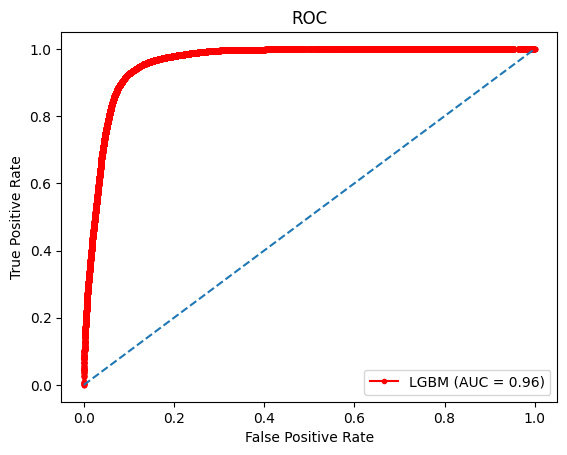

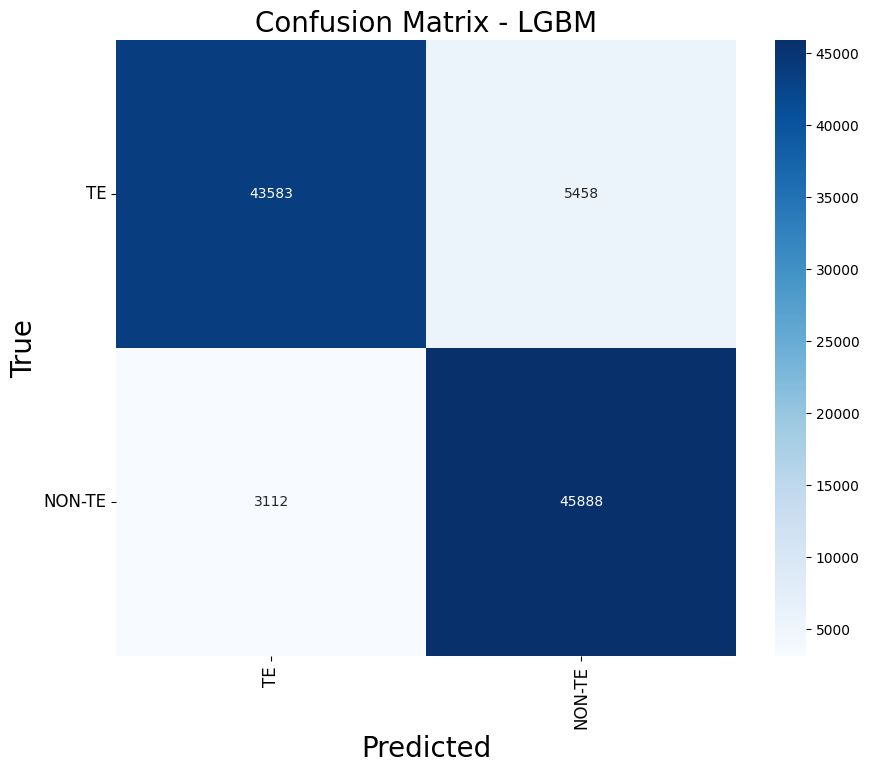

In [14]:
lgbm2=LGBMClassifier(
    n_estimators=100
)
lgbm2.fit(feature, labels)

# Cross-validation accuracy
score_lgbm2 = cross_val_score(lgbm2, feature, labels, cv=10)
res = score_lgbm2.mean()
print('Mean of Accuracies: ', res * 100, end='\n')

# Cross-validated predictions
pred_prob = cross_val_predict(lgbm2, feature, labels, cv=10, method='predict_proba')
y_pred_test = cross_val_predict(lgbm2, feature, labels, cv=10)

# ------------------ Metrics ------------------
cm_lgbm2 = confusion_matrix(labels, y_pred_test)
print(cm_lgbm2)

cr_lgbm2 = classification_report(labels, y_pred_test)
print(cr_lgbm2)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(labels, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(labels, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity
sensitivity1 = cm_lgbm2[0, 0] / (cm_lgbm2[0, 0] + cm_lgbm2[0, 1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_lgbm2[1, 1] / (cm_lgbm2[1, 0] + cm_lgbm2[1, 1])
print('Specificity : ', specificity1)

# ------------------ AUC SCORE ------------------
fpr_lgbm2 = {}
tpr_lgbm2 = {}
thresh_lgbm2 = {}

n_class = 2
for i in range(n_class):
    fpr_lgbm2[i], tpr_lgbm2[i], thresh_lgbm2[i] = roc_curve(labels, pred_prob[:, i], pos_label=i)
    roc_lgbm2 = auc(fpr_lgbm2[i], tpr_lgbm2[i])
roc_lgbm2

# ------------------ ROC Plot ------------------
plt.title('ROC')
plt.plot(fpr_lgbm2[i], tpr_lgbm2[i], marker='.', color='red',
         label='LGBM (AUC = %0.2f)' % roc_lgbm2)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

plt.legend()
plt.savefig('cross-val-test-lgbm2_roc.png')
plt.show()

# ------------------ Confusion Matrix Heatmap ------------------
cm_lgbm2 = confusion_matrix(labels, y_pred_test)
class_names = ['TE', 'NON-TE']

fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm_lgbm2, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - LGBM', fontsize=20)

plt.savefig('lgbm2_cross-val_cm.png')
plt.show()


In [ ]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    matthews_corrcoef, roc_curve, auc
)

# ------------------ Model ------------------
dt2 = DecisionTreeClassifier()
dt2.fit(feature, labels)

# Cross-validation accuracy
score_dt2 = cross_val_score(dt2, feature, labels, cv=10)
res = score_dt2.mean()
print('Mean of Accuracies: ', res * 100, end='\n')

# Cross-validated predictions
pred_prob = cross_val_predict(dt2, feature, labels, cv=10, method='predict_proba')
y_pred_test = cross_val_predict(dt2, feature, labels, cv=10)

# ------------------ Metrics ------------------
cm_dt2 = confusion_matrix(labels, y_pred_test)
print(cm_dt2)

cr_dt2 = classification_report(labels, y_pred_test)
print(cr_dt2)

print("Accuracy {0:.2f}%".format(100 * accuracy_score(labels, y_pred_test)))

# Matthews correlation coefficient (MCC)
mcc = matthews_corrcoef(labels, y_pred_test)
print("MCC ---> {0}".format(mcc))

# Sensitivity & Specificity
sensitivity1 = cm_dt2[0, 0] / (cm_dt2[0, 0] + cm_dt2[0, 1])
print('Sensitivity : ', sensitivity1)

specificity1 = cm_dt2[1, 1] / (cm_dt2[1, 0] + cm_dt2[1, 1])
print('Specificity : ', specificity1)

# ------------------ AUC SCORE ------------------
fpr_dt2 = {}
tpr_dt2 = {}
thresh_dt2 = {}

n_class = 2
for i in range(n_class):
    fpr_dt2[i], tpr_dt2[i], thresh_dt2[i] = roc_curve(labels, pred_prob[:, i], pos_label=i)
    roc_dt2 = auc(fpr_dt2[i], tpr_dt2[i])
roc_dt2

# ------------------ ROC Plot ------------------
plt.title('ROC')
plt.plot(fpr_dt2[i], tpr_dt2[i], marker='.', color='red',
         label='Decision Tree (AUC = %0.2f)' % roc_dt2)

plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.axis('tight')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

plt.legend()
plt.savefig('cross-val-test-dt2_roc.png')
plt.show()

# ------------------ Confusion Matrix Heatmap ------------------
cm_dt2 = confusion_matrix(labels, y_pred_test)
class_names = ['TE', 'NON-TE']

fig = plt.figure(figsize=(10, 8))
ax = plt.subplot()
sns.heatmap(cm_dt2, annot=True, ax=ax, fmt='g', cmap="Blues")  # heatmap with color

# Labels, title and ticks
ax.set_xlabel('Predicted', fontsize=20)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize=12)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=20)
ax.yaxis.set_ticklabels(class_names, fontsize=12)
plt.yticks(rotation=0)

plt.title('Confusion Matrix - Decision Tree', fontsize=20)

plt.savefig('dt2_cross-val_cm.png')
plt.show()


Mean of Accuracies:  86.90650393817756


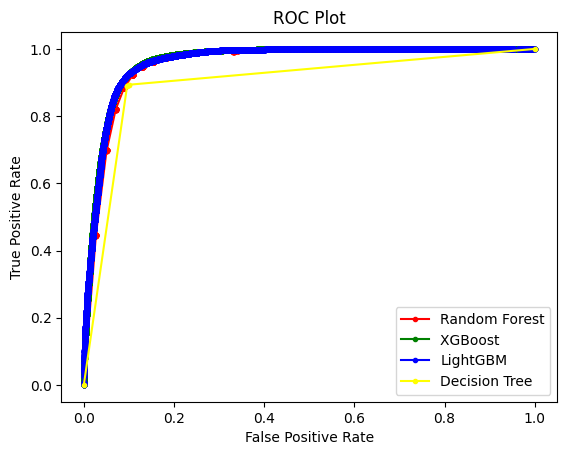

In [ ]:
import matplotlib.pyplot as plt
plt.plot(fpr_rf2[i],tpr_rf2[i], marker='.',color='red',label = 'Random Forest' % roc_rf2)
plt.plot(fpr_xgb2[i],tpr_xgb2[i], marker='.',color='green',label = 'XGBoost ' % roc_xgb2)
plt.plot(fpr_lgbm2[i],tpr_lgbm2[i], marker='.',color='blue',label = 'LightGBM' % roc_lgbm2)
plt.plot(fpr_dt1[i],tpr_dt1[i], marker='.',color='yellow',label = 'Decision Tree' % roc_dt1)


plt.title('ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #q
plt.savefig('cross-val-roc.png')
# Show plot
plt.show()
